# Deutsch-Jozsa: n = 1, 2, 3, 4

All zeros -> **constant**. Anything else -> **balanced**.

In [2]:
# !pip install qiskit qiskit-aer matplotlib pylatexenc

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

sim = AerSimulator()

## n = 1

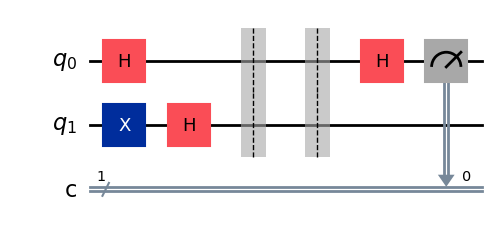

{'0': 1024}


In [3]:
# n = 1, CONSTANT

qc = QuantumCircuit(2, 1)

qc.x(1)
qc.h(0)
qc.h(1)
qc.barrier()

# oracle: f(x) = 0, do nothing
qc.barrier()

qc.h(0)
qc.measure(0, 0)

display(qc.draw(output="mpl"))
print(sim.run(transpile(qc, sim), shots=1024).result().get_counts())

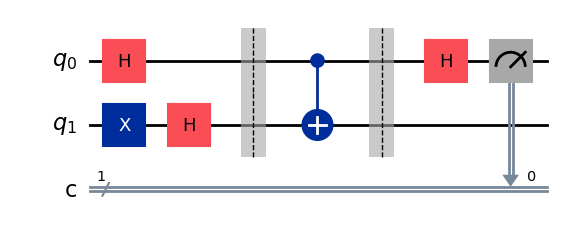

{'1': 1024}


In [4]:
# n = 1, BALANCED

qc = QuantumCircuit(2, 1)

qc.x(1)
qc.h(0)
qc.h(1)
qc.barrier()

# oracle: f(x) = x
qc.cx(0, 1)
qc.barrier()

qc.h(0)
qc.measure(0, 0)

display(qc.draw(output="mpl"))
print(sim.run(transpile(qc, sim), shots=1024).result().get_counts())

## n = 2

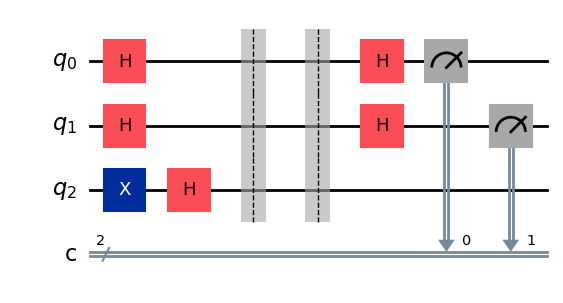

{'00': 1024}


In [5]:
# n = 2, CONSTANT

qc = QuantumCircuit(3, 2)

qc.x(2)
qc.h(0)
qc.h(1)
qc.h(2)
qc.barrier()

# oracle: f(x) = 0, do nothing
qc.barrier()

qc.h(0)
qc.h(1)
qc.measure(0, 0)
qc.measure(1, 1)

display(qc.draw(output="mpl"))
print(sim.run(transpile(qc, sim), shots=1024).result().get_counts())

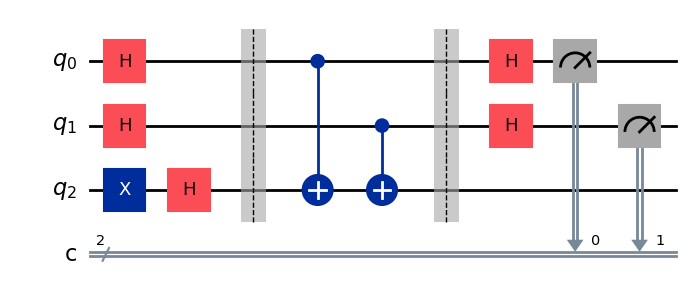

{'11': 1024}


In [6]:
# n = 2, BALANCED

qc = QuantumCircuit(3, 2)

qc.x(2)
qc.h(0)
qc.h(1)
qc.h(2)
qc.barrier()

# oracle: f(x) = x0 XOR x1
qc.cx(0, 2)
qc.cx(1, 2)
qc.barrier()

qc.h(0)
qc.h(1)
qc.measure(0, 0)
qc.measure(1, 1)

display(qc.draw(output="mpl"))
print(sim.run(transpile(qc, sim), shots=1024).result().get_counts())

# Bernstein–Vazirani

- **n** = 4
- **secret s** = `1011`

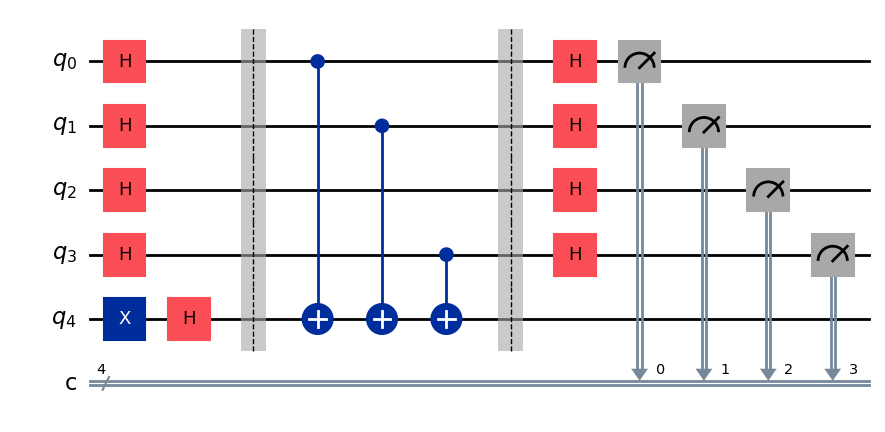

{'1011': 1024}


In [7]:


qc = QuantumCircuit(5, 4)

qc.x(4)
qc.h(0)
qc.h(1)
qc.h(2)
qc.h(3)
qc.h(4)
qc.barrier()

# oracle: f(x) = s . x
# one CNOT for each bit of s that is 1
qc.cx(0, 4)     # s0 = 1
qc.cx(1, 4)     # s1 = 1
                # s2 = 0, no gate
qc.cx(3, 4)     # s3 = 1
qc.barrier()

qc.h(0)
qc.h(1)
qc.h(2)
qc.h(3)
qc.measure(0, 0)
qc.measure(1, 1)
qc.measure(2, 2)
qc.measure(3, 3)

display(qc.draw(output="mpl"))
print(sim.run(transpile(qc, sim), shots=1024).result().get_counts())